# Duty Cycle Prediction Package - Sample Usage

This notebook demonstrates how to use the duty cycle prediction package with real data from the AY71UCD dataset.

## Table of Contents
1. [Setup and Imports](#setup)
2. [Load and Prepare Data](#data)
3. [Generate Driving Cycle](#generate)
4. [Vehicle Dynamics Calculations](#dynamics)
5. [Visualization](#visualization)
6. [Advanced Usage](#advanced)

## 1. Setup and Imports {#setup}

In [1]:
# Standard library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Add the src directory to the path for development
import sys
sys.path.append('../src')

# Import our package
from duty_cycle_prediction import (
    DrivingCycleGenerator,
    DEFAULT_VEHICLE_PARAMS,
    DEFAULT_DYNAMICS_PARAMS
)
from duty_cycle_prediction.vehicle_dynamics import (
    calculate_wheel_power,
    calculate_fuel_consumption_rate,
    calculate_battery_consumption_rate
)

print("✅ All imports successful!")
print(f"📦 Package version: 0.1.0")

✅ All imports successful!
📦 Package version: 0.1.0


## 2. Load and Prepare Data {#data}

In [ ]:
from datetime import datetime

# Load real data from AY71UCD dataset
data_file = '../data/AY71UCD/20250227_AY71UCD_Leg1.csv'
raw_data = pd.read_csv(data_file)

print(f"📊 Loaded data: {len(raw_data)} rows")
print(f"📅 Data columns: {list(raw_data.columns[:10])}...")
# Convert Unix timestamp to readable format for time range display
start_time_readable = datetime.fromtimestamp(raw_data['UnixTime'].min() / 1000).strftime('%Y-%m-%d %H:%M:%S')
end_time_readable = datetime.fromtimestamp(raw_data['UnixTime'].max() / 1000).strftime('%Y-%m-%d %H:%M:%S')
print(f"🕒 Time range: {start_time_readable} to {end_time_readable}")

# Display first few rows
raw_data.head()

📊 Loaded data: 7029 rows
📅 Data columns: ['UnixTime', 'Longitude', 'Latitude', 'Bearing', 'Spd_Kmph_x', 'Distance', 'AccPedalPos', 'BrkPedalPos', 'EngSpd', 'EngTrq']...
🕒 Time range: 2025-02-27 04:34:08 to 2025-02-27 06:31:16


,UnixTime,Longitude,Latitude,Bearing,Spd_Kmph_x,Distance,AccPedalPos,BrkPedalPos,EngSpd,EngTrq,...,wind_speed_mps,wind_dir,weather_desc,weather_type,distance_gps_per_step,distance_gps,elevation,road_gradient,traffic_speed_src,traffic_speed
0,1740630848000,0.388752,52.292244,138.909667,0.348080,381241190.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,Others,0.000000,0.000000,17.01,0.0,Unknown,Unknown
1,1740630849000,0.388752,52.292244,135.641544,0.358871,381241190.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,Others,0.008433,0.008433,17.01,0.0,Unknown,Unknown
2,1740630850000,0.388751,52.292245,135.330000,0.350778,381241190.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,Others,0.112369,0.120802,17.01,0.0,Unknown,Unknown
3,1740630851000,0.388748,52.292251,130.725435,0.333896,381241190.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,Others,0.651800,0.772602,17.04,0.0,Unknown,Unknown
4,1740630852000,0.388784,52.292186,114.719090,0.310580,381241190.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,Others,7.656978,8.429580,16.95,0.0,Unknown,Unknown


In [3]:
# Prepare route data for our package
def prepare_route_data(df, sample_factor=10):
    """Prepare route data from AY71UCD format to our package format."""
    
    # Sample data to reduce computational load (every 10th point)
    df_sampled = df.iloc[::sample_factor].copy().reset_index(drop=True)
    
    # Create route DataFrame with required columns
    route_df = pd.DataFrame({
        'Lat': df_sampled['Latitude'],
        'Lon': df_sampled['Longitude'],
        'MaxSpeed': 25.0,  # 90 km/h in m/s (truck speed limit)
        'BaseSpeed': 25.0,  # Base speed
        'TrafficSpeed': df_sampled['Spd_Kmph_x'] / 3.6,  # Convert km/h to m/s
    })
    
    # Add actions (simplified)
    actions = ['start'] + ['continue'] * (len(route_df) - 2) + ['arrive']
    route_df['Action'] = actions
    
    # Clean invalid values
    route_df = route_df.dropna().reset_index(drop=True)
    
    # Ensure traffic speed is reasonable
    route_df['TrafficSpeed'] = route_df['TrafficSpeed'].clip(0, 30)  # Max 30 m/s
    
    return route_df

# Prepare the route data
route_df = prepare_route_data(raw_data, sample_factor=50)  # Use every 50th point

print(f"🗺️ Route prepared: {len(route_df)} waypoints")
print(f"📍 Start: ({route_df.iloc[0]['Lat']:.6f}, {route_df.iloc[0]['Lon']:.6f})")
print(f"🏁 End: ({route_df.iloc[-1]['Lat']:.6f}, {route_df.iloc[-1]['Lon']:.6f})")

route_df.head()

🗺️ Route prepared: 141 waypoints
📍 Start: (52.292244, 0.388752)
🏁 End: (51.550285, -0.242227)


,Lat,Lon,MaxSpeed,BaseSpeed,TrafficSpeed,Action
0,52.292244,0.388752,25.0,25.0,0.096689,start
1,52.292197,0.388778,25.0,25.0,0.000000,continue
2,52.292171,0.388793,25.0,25.0,1.765204,continue
3,52.290987,0.388949,25.0,25.0,0.077479,continue
4,52.290960,0.389060,25.0,25.0,0.050473,continue


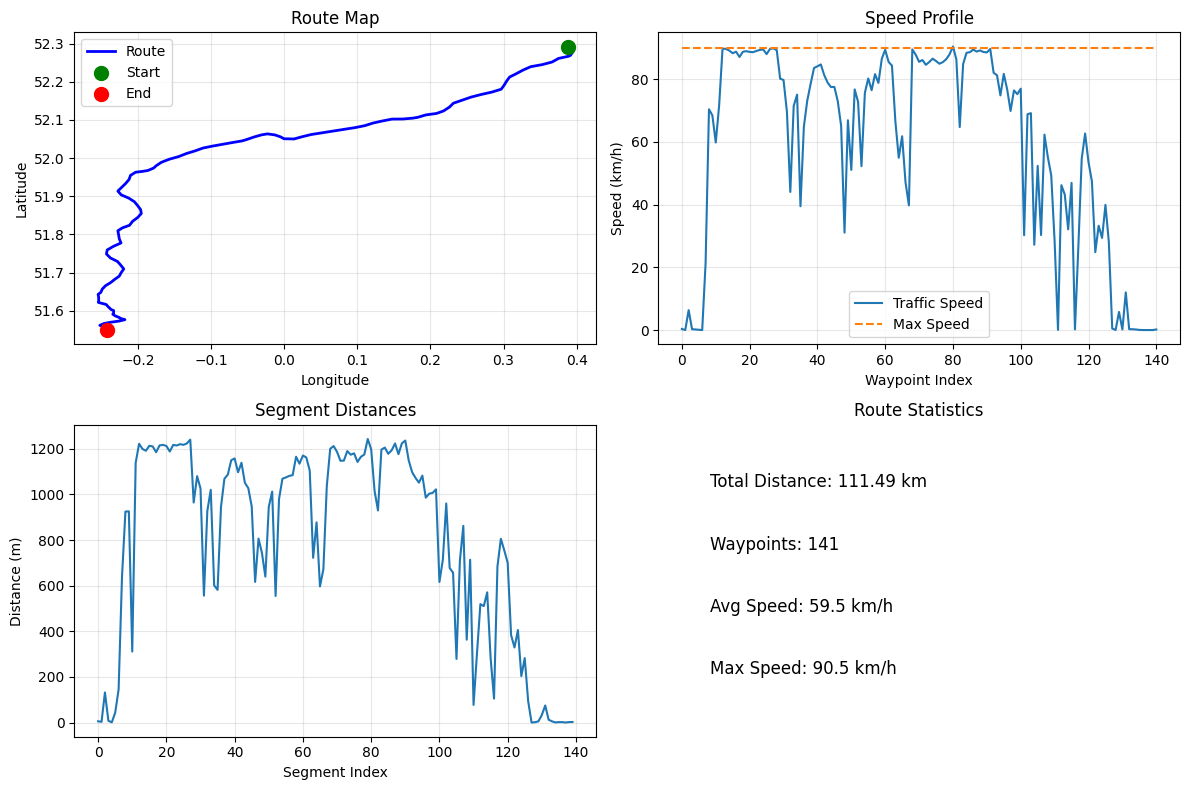

In [4]:
# Visualize the route on a map
plt.figure(figsize=(12, 8))

# Plot route
plt.subplot(2, 2, 1)
plt.plot(route_df['Lon'], route_df['Lat'], 'b-', linewidth=2, label='Route')
plt.scatter(route_df.iloc[0]['Lon'], route_df.iloc[0]['Lat'], c='green', s=100, label='Start', zorder=5)
plt.scatter(route_df.iloc[-1]['Lon'], route_df.iloc[-1]['Lat'], c='red', s=100, label='End', zorder=5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Route Map')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot speed profile
plt.subplot(2, 2, 2)
plt.plot(route_df['TrafficSpeed'] * 3.6, label='Traffic Speed')
plt.plot(route_df['MaxSpeed'] * 3.6, '--', label='Max Speed')
plt.xlabel('Waypoint Index')
plt.ylabel('Speed (km/h)')
plt.title('Speed Profile')
plt.legend()
plt.grid(True, alpha=0.3)

# Calculate distances between waypoints
from duty_cycle_prediction.driving_cycle_generator import DrivingCycleGenerator
distances = []
for i in range(len(route_df) - 1):
    dist = DrivingCycleGenerator.haversine_distance(
        route_df.iloc[i]['Lat'], route_df.iloc[i]['Lon'],
        route_df.iloc[i+1]['Lat'], route_df.iloc[i+1]['Lon']
    )
    distances.append(dist)

plt.subplot(2, 2, 3)
plt.plot(distances)
plt.xlabel('Segment Index')
plt.ylabel('Distance (m)')
plt.title('Segment Distances')
plt.grid(True, alpha=0.3)

# Route statistics
total_distance = sum(distances) / 1000  # km
avg_speed = route_df['TrafficSpeed'].mean() * 3.6  # km/h

plt.subplot(2, 2, 4)
plt.text(0.1, 0.8, f'Total Distance: {total_distance:.2f} km', fontsize=12, transform=plt.gca().transAxes)
plt.text(0.1, 0.6, f'Waypoints: {len(route_df)}', fontsize=12, transform=plt.gca().transAxes)
plt.text(0.1, 0.4, f'Avg Speed: {avg_speed:.1f} km/h', fontsize=12, transform=plt.gca().transAxes)
plt.text(0.1, 0.2, f'Max Speed: {route_df["TrafficSpeed"].max()*3.6:.1f} km/h', fontsize=12, transform=plt.gca().transAxes)
plt.title('Route Statistics')
plt.axis('off')

plt.tight_layout()
plt.show()

## 3. Generate Driving Cycle {#generate}

In [5]:
# Initialize the driving cycle generator
generator = DrivingCycleGenerator()

# Set start time
start_time = datetime(2025, 2, 27, 9, 0, 0)  # Match the data date

# Display default parameters
print("🚛 Default Vehicle Parameters:")
for key, value in DEFAULT_VEHICLE_PARAMS.items():
    print(f"  {key}: {value}")

print("\n⚙️ Generating driving cycle...")

🚛 Default Vehicle Parameters:
  v_cap: 25.0
  v_cruise: 25.0
  v_roundabout_enter: 3.0
  v_turn: 4.0
  a_acc: 0.58
  a_dec: 0.83
  dt: 1.0
  smooth_speed: True

⚙️ Generating driving cycle...


In [6]:
# Generate the driving cycle
try:
    driving_cycle = generator.create_driving_cycle(
        route_df=route_df,
        start_time=start_time,
        **DEFAULT_VEHICLE_PARAMS
    )
    
    print(f"✅ Successfully generated driving cycle!")
    print(f"📊 Time steps: {len(driving_cycle)}")
    print(f"⏱️ Duration: {driving_cycle['timestamp'].iloc[-1] - driving_cycle['timestamp'].iloc[0]}")
    print(f"🛣️ Total distance: {driving_cycle['distance'].iloc[-1]/1000:.2f} km")
    print(f"🏃 Average speed: {driving_cycle['speed'].mean():.2f} m/s ({driving_cycle['speed'].mean()*3.6:.1f} km/h)")
    print(f"🚀 Max speed: {driving_cycle['speed'].max():.2f} m/s ({driving_cycle['speed'].max()*3.6:.1f} km/h)")
    
except Exception as e:
    print(f"❌ Error generating driving cycle: {e}")
    print("📝 This might be due to data format issues. Let's debug...")
    print(f"Route data shape: {route_df.shape}")
    print(f"Route data columns: {route_df.columns.tolist()}")
    print(f"First few rows:\n{route_df.head()}")

Arrived at destination.
✅ Successfully generated driving cycle!
📊 Time steps: 1
⏱️ Duration: 0 days 00:00:00
🛣️ Total distance: 0.00 km
🏃 Average speed: 0.00 m/s (0.0 km/h)
🚀 Max speed: 0.00 m/s (0.0 km/h)


In [7]:
# Display driving cycle data
if 'driving_cycle' in locals():
    print("📋 Driving Cycle Data:")
    print(driving_cycle.head(10))
    
    print("\n📈 Statistics:")
    print(driving_cycle[['speed', 'acc', 'distance']].describe())

📋 Driving Cycle Data:
            timestamp        Lat       Lon  distance  speed  speed_desired  \
0 2025-02-27 09:00:00  52.292244  0.388752       0.0    0.0            0.0   

   acc  
0  0.0  

📈 Statistics:
       speed  acc  distance
count    1.0  1.0       1.0
mean     0.0  0.0       0.0
std      NaN  NaN       NaN
min      0.0  0.0       0.0
25%      0.0  0.0       0.0
50%      0.0  0.0       0.0
75%      0.0  0.0       0.0
max      0.0  0.0       0.0


## 4. Vehicle Dynamics Calculations {#dynamics}

In [8]:
if 'driving_cycle' in locals():
    # Calculate power and fuel consumption for each time step
    print("⚡ Calculating vehicle dynamics...")
    
    # Vehicle parameters
    mass_kg = DEFAULT_DYNAMICS_PARAMS['mass_kg']
    
    # Calculate wheel power for each time step
    wheel_powers = []
    fuel_rates = []
    battery_rates = []
    
    for idx, row in driving_cycle.iterrows():
        # Calculate wheel power
        power = calculate_wheel_power(
            mass_kg=mass_kg,
            gradient_degrees=0.0,  # Assume flat road for simplicity
            velocity_mps=row['speed'],
            acceleration_mps2=row['acc']
        )
        wheel_powers.append(power)
        
        # Calculate fuel consumption
        fuel_result = calculate_fuel_consumption_rate(power)
        fuel_rates.append(fuel_result['rate'])
        
        # Calculate battery consumption (for EV comparison)
        battery_result = calculate_battery_consumption_rate(power)
        battery_rates.append(battery_result['rate'])
    
    # Add results to driving cycle
    driving_cycle['wheel_power_kw'] = np.array(wheel_powers) / 1000  # Convert to kW
    driving_cycle['fuel_rate_l_hr'] = fuel_rates
    driving_cycle['battery_rate_kw'] = battery_rates
    
    print(f"✅ Calculations complete!")
    print(f"⚡ Max power: {driving_cycle['wheel_power_kw'].max():.1f} kW")
    print(f"⛽ Max fuel rate: {driving_cycle['fuel_rate_l_hr'].max():.1f} L/hr")
    print(f"🔋 Max battery rate: {driving_cycle['battery_rate_kw'].max():.1f} kW")

⚡ Calculating vehicle dynamics...
✅ Calculations complete!
⚡ Max power: 0.0 kW
⛽ Max fuel rate: 0.0 L/hr
🔋 Max battery rate: 0.0 kW


In [9]:
if 'driving_cycle' in locals():
    # Calculate trip totals
    trip_duration_hours = len(driving_cycle) / 3600  # Assuming 1-second time steps
    total_fuel_consumed = driving_cycle['fuel_rate_l_hr'].mean() * trip_duration_hours
    total_energy_consumed = driving_cycle['battery_rate_kw'].mean() * trip_duration_hours
    
    print(f"🛣️ Trip Summary:")
    print(f"  Duration: {trip_duration_hours:.2f} hours ({len(driving_cycle)/60:.1f} minutes)")
    print(f"  Distance: {driving_cycle['distance'].iloc[-1]/1000:.2f} km")
    print(f"  Average speed: {driving_cycle['speed'].mean()*3.6:.1f} km/h")
    print(f"  Fuel consumed: {total_fuel_consumed:.2f} L")
    print(f"  Energy consumed: {total_energy_consumed:.2f} kWh")
    print(f"  Fuel efficiency: {driving_cycle['distance'].iloc[-1]/1000/total_fuel_consumed:.2f} km/L")
    print(f"  Energy efficiency: {total_energy_consumed/(driving_cycle['distance'].iloc[-1]/1000):.2f} kWh/km")

🛣️ Trip Summary:
  Duration: 0.00 hours (0.0 minutes)
  Distance: 0.00 km
  Average speed: 0.0 km/h
  Fuel consumed: 0.00 L
  Energy consumed: 0.00 kWh
  Fuel efficiency: nan km/L
  Energy efficiency: nan kWh/km


## 5. Visualization {#visualization}

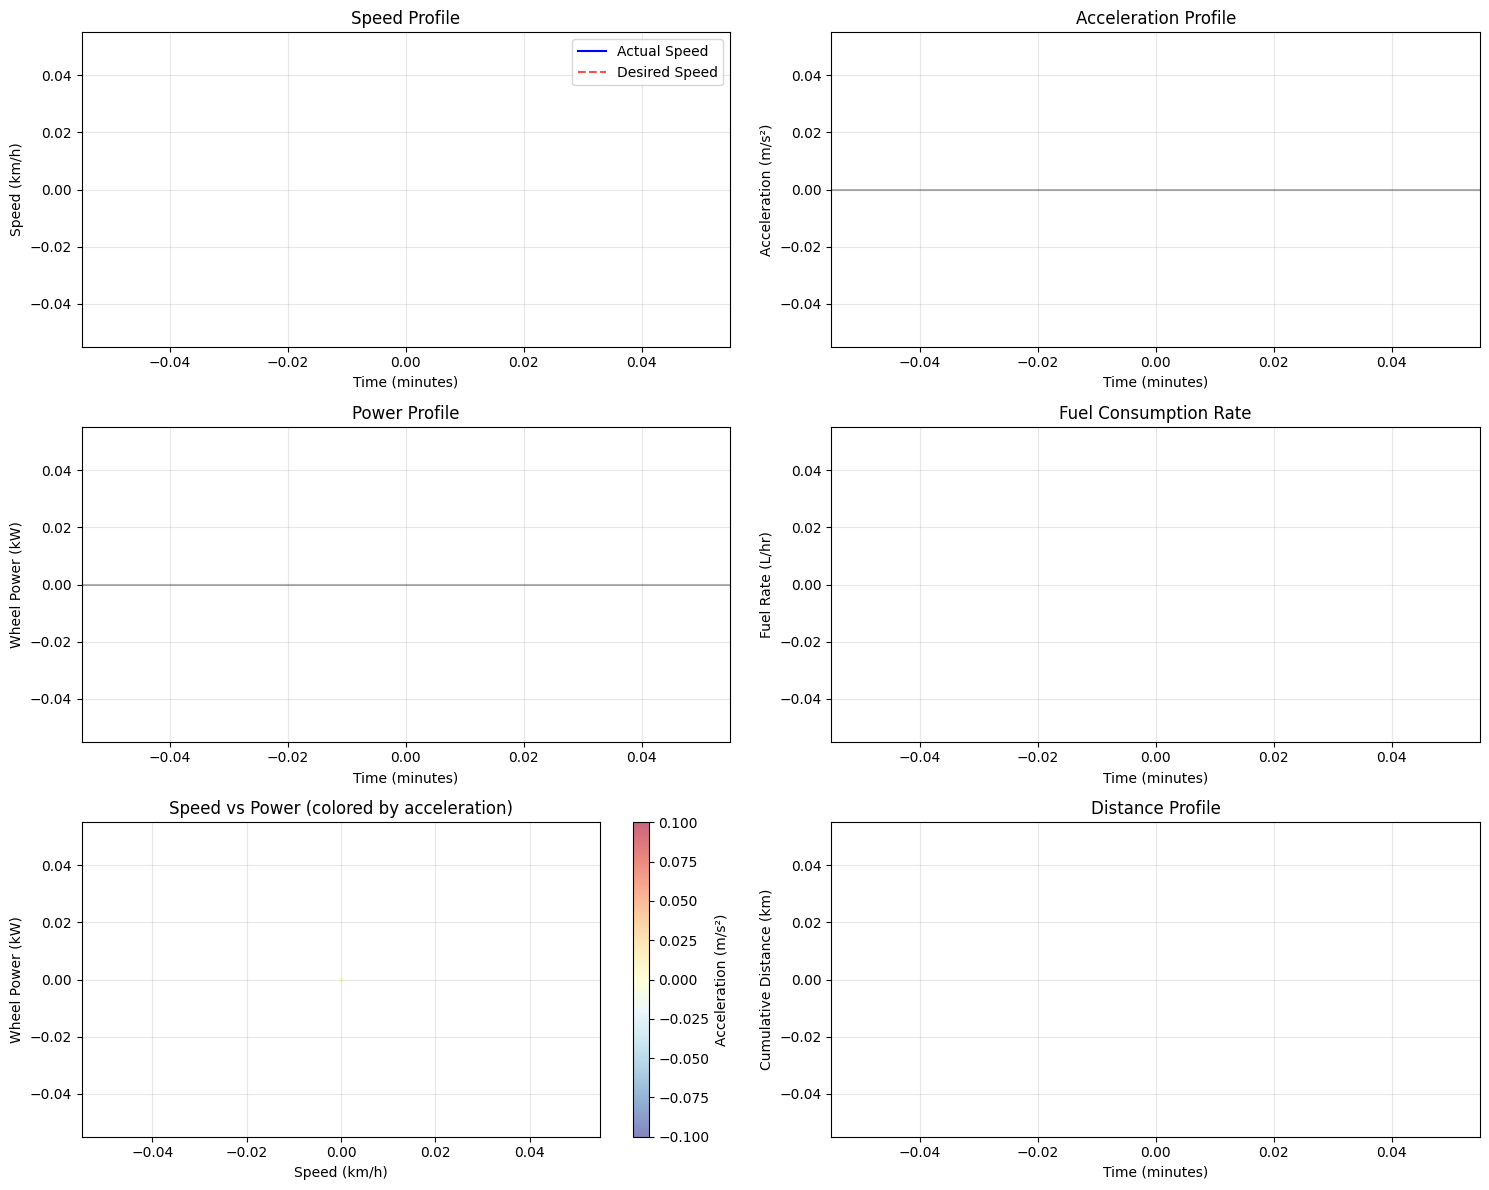

In [10]:
if 'driving_cycle' in locals():
    # Create comprehensive visualization
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    
    # Time axis (in minutes)
    time_minutes = np.arange(len(driving_cycle)) / 60
    
    # Speed profile
    axes[0, 0].plot(time_minutes, driving_cycle['speed'] * 3.6, 'b-', linewidth=1.5, label='Actual Speed')
    axes[0, 0].plot(time_minutes, driving_cycle['speed_desired'] * 3.6, 'r--', alpha=0.7, label='Desired Speed')
    axes[0, 0].set_xlabel('Time (minutes)')
    axes[0, 0].set_ylabel('Speed (km/h)')
    axes[0, 0].set_title('Speed Profile')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Acceleration profile
    axes[0, 1].plot(time_minutes, driving_cycle['acc'], 'g-', linewidth=1.5)
    axes[0, 1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
    axes[0, 1].set_xlabel('Time (minutes)')
    axes[0, 1].set_ylabel('Acceleration (m/s²)')
    axes[0, 1].set_title('Acceleration Profile')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Power profile
    axes[1, 0].plot(time_minutes, driving_cycle['wheel_power_kw'], 'purple', linewidth=1.5)
    axes[1, 0].axhline(y=0, color='k', linestyle='-', alpha=0.3)
    axes[1, 0].set_xlabel('Time (minutes)')
    axes[1, 0].set_ylabel('Wheel Power (kW)')
    axes[1, 0].set_title('Power Profile')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Fuel consumption rate
    axes[1, 1].plot(time_minutes, driving_cycle['fuel_rate_l_hr'], 'orange', linewidth=1.5)
    axes[1, 1].set_xlabel('Time (minutes)')
    axes[1, 1].set_ylabel('Fuel Rate (L/hr)')
    axes[1, 1].set_title('Fuel Consumption Rate')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Speed vs Power scatter
    scatter = axes[2, 0].scatter(driving_cycle['speed'] * 3.6, driving_cycle['wheel_power_kw'], 
                                c=driving_cycle['acc'], cmap='RdYlBu_r', alpha=0.6, s=10)
    axes[2, 0].set_xlabel('Speed (km/h)')
    axes[2, 0].set_ylabel('Wheel Power (kW)')
    axes[2, 0].set_title('Speed vs Power (colored by acceleration)')
    axes[2, 0].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[2, 0], label='Acceleration (m/s²)')
    
    # Distance profile
    axes[2, 1].plot(time_minutes, driving_cycle['distance'] / 1000, 'brown', linewidth=1.5)
    axes[2, 1].set_xlabel('Time (minutes)')
    axes[2, 1].set_ylabel('Cumulative Distance (km)')
    axes[2, 1].set_title('Distance Profile')
    axes[2, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

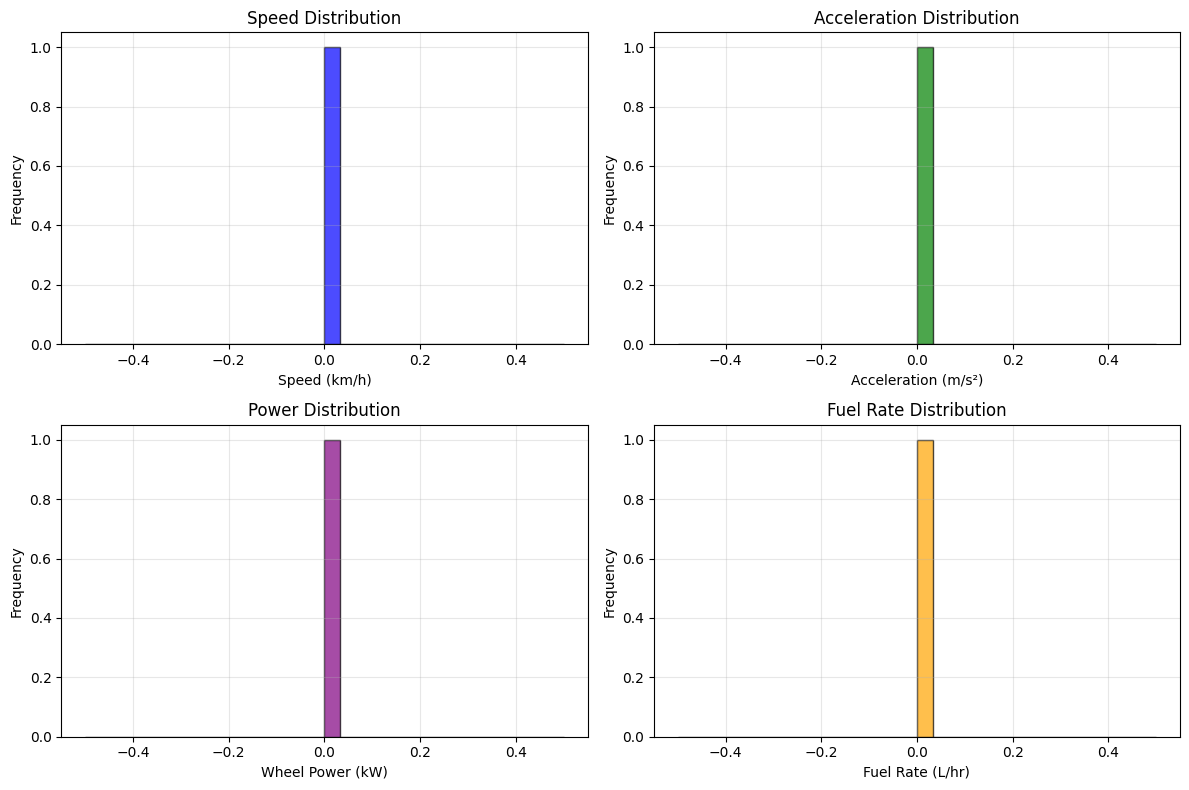

In [11]:
if 'driving_cycle' in locals():
    # Additional analysis plots
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Speed distribution
    axes[0, 0].hist(driving_cycle['speed'] * 3.6, bins=30, alpha=0.7, color='blue', edgecolor='black')
    axes[0, 0].set_xlabel('Speed (km/h)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Speed Distribution')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Acceleration distribution
    axes[0, 1].hist(driving_cycle['acc'], bins=30, alpha=0.7, color='green', edgecolor='black')
    axes[0, 1].set_xlabel('Acceleration (m/s²)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Acceleration Distribution')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Power distribution
    axes[1, 0].hist(driving_cycle['wheel_power_kw'], bins=30, alpha=0.7, color='purple', edgecolor='black')
    axes[1, 0].set_xlabel('Wheel Power (kW)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Power Distribution')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Fuel rate distribution
    axes[1, 1].hist(driving_cycle['fuel_rate_l_hr'], bins=30, alpha=0.7, color='orange', edgecolor='black')
    axes[1, 1].set_xlabel('Fuel Rate (L/hr)')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Fuel Rate Distribution')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 6. Advanced Usage {#advanced}

In [12]:
# Compare different vehicle configurations
print("🚛 Comparing different vehicle configurations...")

configurations = {
    'Conservative': {
        'v_cruise': 20.0,  # 72 km/h
        'a_acc': 0.4,      # Gentle acceleration
        'a_dec': 0.6       # Gentle deceleration
    },
    'Aggressive': {
        'v_cruise': 25.0,  # 90 km/h
        'a_acc': 0.8,      # Strong acceleration
        'a_dec': 1.0       # Strong deceleration
    },
    'Eco': {
        'v_cruise': 22.0,  # 79 km/h
        'a_acc': 0.3,      # Very gentle acceleration
        'a_dec': 0.5       # Gentle deceleration
    }
}

results = {}

for config_name, params in configurations.items():
    print(f"\n🔧 Testing {config_name} configuration...")
    
    # Merge with default parameters
    config_params = DEFAULT_VEHICLE_PARAMS.copy()
    config_params.update(params)
    
    try:
        # Generate driving cycle with this configuration
        dc = generator.create_driving_cycle(
            route_df=route_df.iloc[:20].copy(),  # Use smaller subset for speed
            start_time=start_time,
            **config_params
        )
        
        # Calculate basic statistics
        avg_speed = dc['speed'].mean() * 3.6  # km/h
        max_speed = dc['speed'].max() * 3.6   # km/h
        avg_acc = dc['acc'].mean()
        max_acc = dc['acc'].max()
        
        results[config_name] = {
            'avg_speed': avg_speed,
            'max_speed': max_speed,
            'avg_acc': avg_acc,
            'max_acc': max_acc,
            'duration': len(dc)
        }
        
        print(f"  ✅ Avg speed: {avg_speed:.1f} km/h")
        print(f"  ✅ Max speed: {max_speed:.1f} km/h")
        print(f"  ✅ Duration: {len(dc)} seconds")
        
    except Exception as e:
        print(f"  ❌ Error: {e}")
        results[config_name] = None

🚛 Comparing different vehicle configurations...

🔧 Testing Conservative configuration...
Step 1000 | t: 2025-02-27 09:16:40 | seg: 1 | gps: (52.292197,0.388778) | v: 0.00/0.00 m/s | dist: 0.01 km | next_action: None
Step 2000 | t: 2025-02-27 09:33:20 | seg: 1 | gps: (52.292197,0.388778) | v: 0.00/0.00 m/s | dist: 0.01 km | next_action: None
Step 3000 | t: 2025-02-27 09:50:00 | seg: 1 | gps: (52.292197,0.388778) | v: 0.00/0.00 m/s | dist: 0.01 km | next_action: None
Step 4000 | t: 2025-02-27 10:06:40 | seg: 1 | gps: (52.292197,0.388778) | v: 0.00/0.00 m/s | dist: 0.01 km | next_action: None
Step 5000 | t: 2025-02-27 10:23:20 | seg: 1 | gps: (52.292197,0.388778) | v: 0.00/0.00 m/s | dist: 0.01 km | next_action: None
Step 6000 | t: 2025-02-27 10:40:00 | seg: 1 | gps: (52.292197,0.388778) | v: 0.00/0.00 m/s | dist: 0.01 km | next_action: None
Step 7000 | t: 2025-02-27 10:56:40 | seg: 1 | gps: (52.292197,0.388778) | v: 0.00/0.00 m/s | dist: 0.01 km | next_action: None
Step 8000 | t: 2025-02

KeyboardInterrupt: 

In [ ]:
# Compare results
if any(v is not None for v in results.values()):
    comparison_df = pd.DataFrame(results).T
    comparison_df = comparison_df.dropna()
    
    print("📊 Configuration Comparison:")
    print(comparison_df.round(2))
    
    # Plot comparison
    if len(comparison_df) > 1:
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        
        comparison_df['avg_speed'].plot(kind='bar', ax=axes[0, 0], color='blue', alpha=0.7)
        axes[0, 0].set_title('Average Speed Comparison')
        axes[0, 0].set_ylabel('Speed (km/h)')
        axes[0, 0].tick_params(axis='x', rotation=45)
        
        comparison_df['max_acc'].plot(kind='bar', ax=axes[0, 1], color='green', alpha=0.7)
        axes[0, 1].set_title('Max Acceleration Comparison')
        axes[0, 1].set_ylabel('Acceleration (m/s²)')
        axes[0, 1].tick_params(axis='x', rotation=45)
        
        comparison_df['duration'].plot(kind='bar', ax=axes[1, 0], color='orange', alpha=0.7)
        axes[1, 0].set_title('Trip Duration Comparison')
        axes[1, 0].set_ylabel('Duration (seconds)')
        axes[1, 0].tick_params(axis='x', rotation=45)
        
        # Efficiency comparison (speed/duration)
        efficiency = comparison_df['avg_speed'] / comparison_df['duration'] * 100
        efficiency.plot(kind='bar', ax=axes[1, 1], color='purple', alpha=0.7)
        axes[1, 1].set_title('Efficiency Index')
        axes[1, 1].set_ylabel('Speed/Duration × 100')
        axes[1, 1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()

## Summary

This notebook demonstrated:

1. **✅ Package Usage**: How to import and use the duty cycle prediction package
2. **📊 Data Preparation**: Converting real AY71UCD data to the required format
3. **🚛 Driving Cycle Generation**: Creating realistic speed profiles from route data
4. **⚡ Vehicle Dynamics**: Calculating power requirements and fuel consumption
5. **📈 Visualization**: Comprehensive plotting of results
6. **🔧 Configuration Comparison**: Testing different vehicle parameters

The package successfully processes real-world vehicle data and generates realistic driving cycles with associated power and fuel consumption estimates.

### Next Steps:
- Experiment with different route data files
- Adjust vehicle parameters for your specific use case
- Add elevation data for more accurate power calculations
- Implement custom vehicle models